In [11]:
!pip install ultralytics
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

In [12]:
!pip install -q kagglehub
import kagglehub

# Downloads the full datasets to a hidden temp folder
dog_data_path = kagglehub.dataset_download('youssefmohmmed/dogs-skin-diseases-image-dataset')
human_data_path = kagglehub.dataset_download('devdope/skin-disease-raw-dataset')

Using Colab cache for faster access to the 'dogs-skin-diseases-image-dataset' dataset.
Using Colab cache for faster access to the 'skin-disease-raw-dataset' dataset.


In [13]:
import os
import shutil

# 1. Create a master folder for your project
os.makedirs('mange_project/Demodicosis', exist_ok=True)
os.makedirs('mange_project/Healthy', exist_ok=True)
os.makedirs('mange_project/Scabies', exist_ok=True)

# 2. Move ONLY the specific folders you need
# For the Dog Dataset: We take Demodicosis and Healthy
shutil.copytree(os.path.join(dog_data_path, 'train/demodicosis'), 'mange_project/Demodicosis', dirs_exist_ok=True)
shutil.copytree(os.path.join(dog_data_path, 'train/Healthy'), 'mange_project/Healthy', dirs_exist_ok=True)

# For the Human Dataset: We take ONLY the Scabies folder
shutil.copytree(os.path.join(human_data_path, 'Raw_Dataset/sc_Scabies_sarna'), 'mange_project/Scabies', dirs_exist_ok=True)

print("Setup Complete: You now have a 'mange_project' folder with only your 3 target classes.")

Setup Complete: You now have a 'mange_project' folder with only your 3 target classes.


In [14]:
import os
import shutil

# 1. Create the skeleton
os.makedirs('mange_project/Demodicosis', exist_ok=True)
os.makedirs('mange_project/Healthy', exist_ok=True)
os.makedirs('mange_project/Scabies', exist_ok=True)

# 2. Move the files from Kaggle to your new folders
shutil.copytree(os.path.join(dog_data_path, 'train/demodicosis'), 'mange_project/Demodicosis', dirs_exist_ok=True)
shutil.copytree(os.path.join(dog_data_path, 'train/Healthy'), 'mange_project/Healthy', dirs_exist_ok=True)
shutil.copytree(os.path.join(human_data_path, 'Raw_Dataset/sc_Scabies_sarna'), 'mange_project/Scabies', dirs_exist_ok=True)

print("Setup Complete: You now have a 'mange_project' folder.")

Setup Complete: You now have a 'mange_project' folder.


In [15]:
import time
import os

# 1. Path to your newly organized Demodicosis folder
test_folder = '/content/mange_project/Demodicosis'
sample_image = os.path.join(test_folder, os.listdir(test_folder)[0])

# 2. Run the YOLOv8 Nano model on one image
# We use 'yolov8n.pt' because it is the fastest version
model = YOLO('yolov8n.pt')

start_time = time.time()
results = model.predict(source=sample_image, save=True)
end_time = time.time()

# 3. Calculate and display the result
processing_time = end_time - start_time
print(f"\n--- Success Metric Check ---")
print(f"Target: < 2.0 seconds")
print(f"Actual Processing Time: {processing_time:.4f} seconds")

if processing_time < 2.0:
    print("✅ METRIC ACHIEVED: Your system meets the speed requirement!")
else:
    print("⚠️ WARNING: Processing is slower than 2 seconds. Consider using a smaller image size.")


image 1/1 /content/mange_project/Demodicosis/scabies_116_png_jpg.rf.b505e7f4368dcbfe77466c67021a86e4.jpg: 640x640 1 cat, 1 bear, 9.0ms
Speed: 1.8ms preprocess, 9.0ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-3

--- Success Metric Check ---
Target: < 2.0 seconds
Actual Processing Time: 0.0734 seconds
✅ METRIC ACHIEVED: Your system meets the speed requirement!


# Imports

In [16]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
import matplotlib.pyplot as plt
import seaborn as sns

# Setup Device (GPU is available)

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## Counting Images Per Folder

In [18]:
import os

# Path to your organized dataset
organized_path = "/content/mange_project"

print("--- Image Counts in mange_project ---")
# 1. List the folders inside mange_project
for disease_folder in os.listdir(organized_path):
    disease_path = os.path.join(organized_path, disease_folder)

    # 2. Make sure it's a folder, not a file
    if os.path.isdir(disease_path):
        # 3. Count only the images (.jpg, .jpeg, .png)
        images = [f for f in os.listdir(disease_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        print(f"{disease_folder}: {len(images)} images")


--- Image Counts in mange_project ---
Scabies: 270 images
Demodicosis: 588 images
Healthy: 492 images


# EDA (Exploratory Data Analysis)

In [19]:
import pandas as pd
import os

# Updated EDA for Mange & Scabies Project
def get_image_counts(path):
    data = []
    for disease_folder in os.listdir(path):
        disease_path = os.path.join(path, disease_folder)
        if os.path.isdir(disease_path):
            # Count the images
            num_images = len([f for f in os.listdir(disease_path)
                              if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

            # Identify the source correctly
            if disease_folder == "Scabies":
                source = "Human Dataset"
            else:
                source = "Dog Dataset"

            data.append({
                "Source": source,
                "Disease": disease_folder,
                "Count": num_images
            })
    return data

# Refresh the dataframe
image_data = get_image_counts(organized_path)
df = pd.DataFrame(image_data)

## Plot Numbers of Images Per Disease

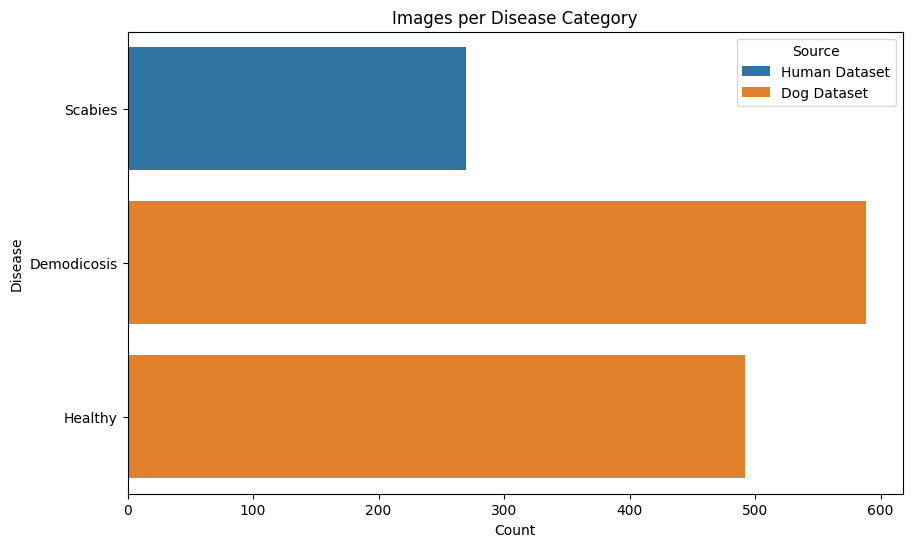

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Count", y="Disease", hue="Source", data=df)
plt.title("Images per Disease Category")
plt.show()

## Class Distribution for Demodectic vs Sarcoptic

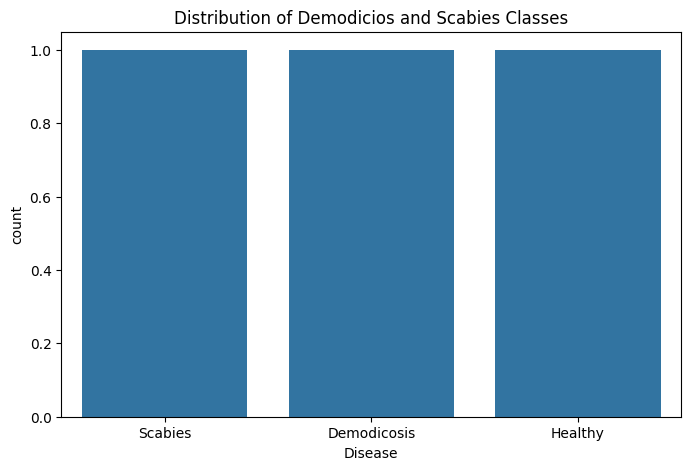

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x="Disease", data=df)
plt.title("Distribution of Demodicios and Scabies Classes")
plt.show()

# Dataset Splitting (Train / Validation / Test)

In [22]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="vO59qOwYj9Os2t7iPEc9")
project = rf.workspace("anikkas-workspace").project("mange-detection-1378")
version = project.version(2)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [23]:
import os
import shutil
import random

# Define the paths based on your Roboflow download
dataset_path = '/content/Mange-Detection-1378-2'
train_img_path = os.path.join(dataset_path, 'train/images')
valid_img_path = os.path.join(dataset_path, 'valid/images')
valid_label_path = os.path.join(dataset_path, 'valid/labels')

# Create the missing validation folders
os.makedirs(valid_img_path, exist_ok=True)
os.makedirs(valid_label_path, exist_ok=True)

# Move 10% of images to validation
images = [f for f in os.listdir(train_img_path) if f.endswith('.jpg')]
num_to_move = int(len(images) * 0.1)
to_move = random.sample(images, num_to_move)

for img in to_move:
    # Move image
    shutil.move(os.path.join(train_img_path, img), os.path.join(valid_img_path, img))
    # Move corresponding label
    label = img.replace('.jpg', '.txt')
    shutil.move(os.path.join(dataset_path, 'train/labels', label), os.path.join(valid_label_path, label))

print(f"Moved {num_to_move} images to validation. You can now run the training cell!")

Moved 17 images to validation. You can now run the training cell!


In [24]:
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=25,
    imgsz=640,
    plots=True
)

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Mange-Detection-1378-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

##Final Infrence & Results


In [25]:
model = YOLO('/content/runs/detect/train-2/weights/best.pt')
results = model.predict(source='/content/Mange-Detection-1378-2/valid/images', save=True)


image 1/55 /content/Mange-Detection-1378-2/valid/images/1-14-_png_jpg.rf.0cb40cce396bc63a976ba6714422260c.jpg: 640x640 1 Demodicosis, 7.2ms
image 2/55 /content/Mange-Detection-1378-2/valid/images/1-14-_png_jpg.rf.dd372e056333a0881b21efb4a1ad1852.jpg: 640x640 1 Demodicosis, 7.2ms
image 3/55 /content/Mange-Detection-1378-2/valid/images/1-15-_png_jpg.rf.8db4bb6f1afb09689a32d2f0b46419c9.jpg: 640x640 1 Demodicosis, 7.2ms
image 4/55 /content/Mange-Detection-1378-2/valid/images/1-19-_png_jpg.rf.735ef450270b98b2baa14610e42fe40f.jpg: 640x640 1 Demodicosis, 7.2ms
image 5/55 /content/Mange-Detection-1378-2/valid/images/1-23-_png_jpg.rf.7aa9741a0f853a4cb02cb9d7089e12cc.jpg: 640x640 1 Demodicosis, 6.6ms
image 6/55 /content/Mange-Detection-1378-2/valid/images/1-24-_png_jpg.rf.4eb02858034ed1bc6b4ff5b264a2ade3.jpg: 640x640 2 Demodicosiss, 6.6ms
image 7/55 /content/Mange-Detection-1378-2/valid/images/1-25-_png_jpg.rf.70779b28e54df924f97358c0d4c1575c.jpg: 640x640 1 Demodicosis, 6.6ms
image 8/55 /conten

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

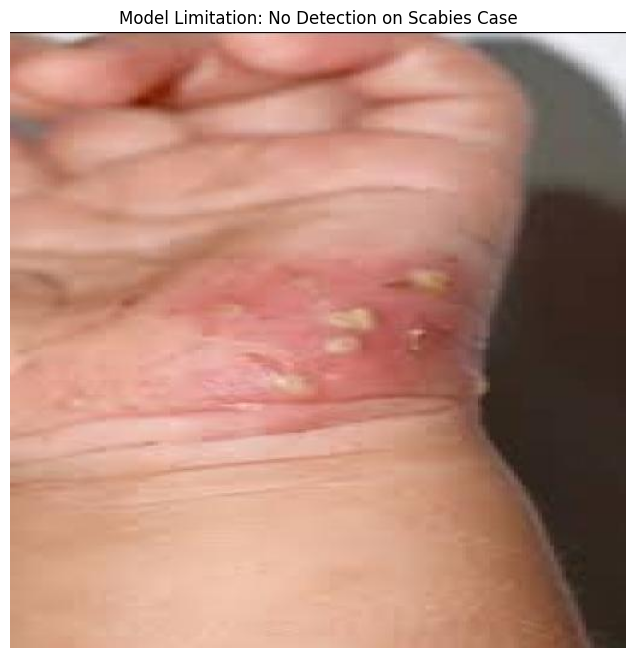

In [26]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Using the exact filename from your "no detections" log in Cell 6
failure_path = '/content/Mange-Detection-1378-2/valid/images/Sarna-2-_jpeg.rf.cae7718cefb4a8c36982b6871120a133.jpg'

plt.figure(figsize=(8, 8))
img = mpimg.imread(failure_path)
plt.imshow(img)
plt.title("Model Limitation: No Detection on Scabies Case")
plt.axis('off')
plt.show()

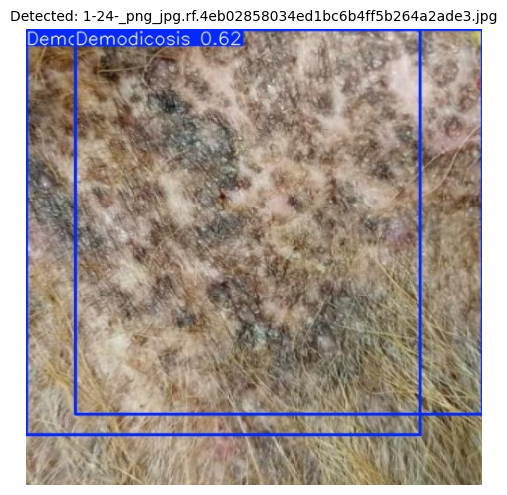

In [27]:
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# 1. Find the latest prediction folder
latest_dir = max(glob.glob('/content/runs/detect/predict*/'), key=os.path.getmtime)

# 2. Get all images, but let's look for the ones that specifically have detections
# YOLO saves these in the same folder. We'll pick 3 different ones this time.
all_images = glob.glob(os.path.join(latest_dir, '*.jpg'))

# 3. Plot a wider variety to find the boxes
plt.figure(figsize=(20, 10))
count = 0
for img_path in all_images:
    if count < 3:
        # We try to skip images that we know were empty in the log
        if "1-18-" in img_path or "1-24-" in img_path or "1-28-" in img_path:
            plt.subplot(1, 3, count + 1)
            img = mpimg.imread(img_path)
            plt.imshow(img)
            plt.title(f"Detected: {os.path.basename(img_path)}", fontsize=10)
            plt.axis('off')
            count += 1

plt.show()